# METADATA HAM1000

In [ ]:
df = pd.read_csv('/content/HAM10000_metadata.csv')
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
df.tail()

,lesion_id,image_id,dx,dx_type,age,sex,localization
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face
10014,HAM_0003521,ISIC_0032258,mel,histo,70.0,female,back


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [ ]:
df.isnull().sum()

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,57
sex,0
localization,0


In [ ]:
df.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


# PREPROCESSING

In [ ]:
# Label lengkap
label_map = {
    'nv'   : 'Melanocytic Nevi',
    'mel'  : 'Melanoma',
    'bkl'  : 'Benign Keratosis',
    'bcc'  : 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratosis',
    'vasc' : 'Vascular Lesion',
    'df'   : 'Dermatofibroma'
}
df['dx'] = df['dx'].map(label_map)

print(f"Total data : {len(df)} sampel")
print(f"Kolom      : {df.columns.tolist()}")
df.head()

Total data : 10015 sampel
Kolom      : ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,Benign Keratosis,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,Benign Keratosis,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,Benign Keratosis,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,Benign Keratosis,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,Benign Keratosis,histo,75.0,male,ear


In [ ]:
print(f"Median age: {df['age'].median()}")

Median age: 50.0


In [ ]:
median_age = df['age'].median()
df['age'].fillna(median_age, inplace=True)
print(f"Missing values after filling: {df['age'].isnull().sum()}")

Missing values after filling: 0


Distribusi variabel 'sex':
sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64


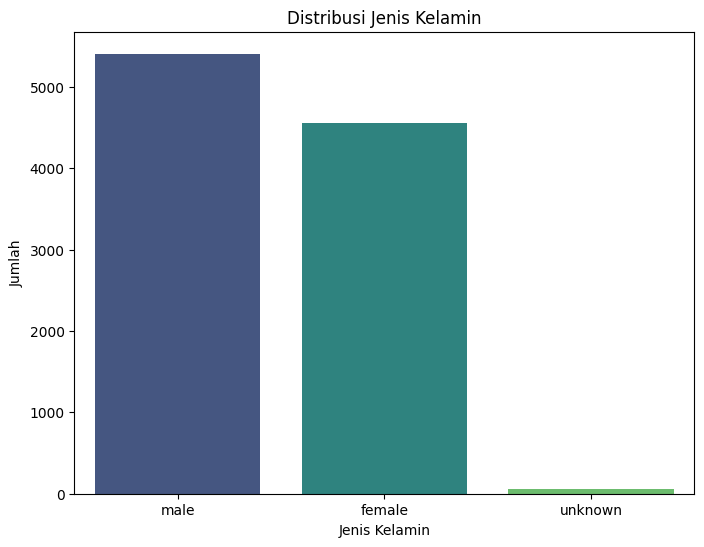

In [ ]:
print('Distribusi variabel \'sex\':')
print(df['sex'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='sex', data=df, palette='viridis')
plt.title('Distribusi Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Jumlah')
plt.show()

In [ ]:
# Identify indices of 'unknown' sex
unknown_indices = df[df['sex'] == 'unknown'].index

if len(unknown_indices) == 0:
    print("Tidak ada nilai 'unknown' di kolom 'sex'.")
else:
    print(f"Jumlah sampel 'unknown' sebelum pengisian: {len(unknown_indices)}")

    # Calculate overall male/female proportions for fallback
    known_sex_counts = df[df['sex'] != 'unknown']['sex'].value_counts(normalize=True)
    overall_male_prop = known_sex_counts.get('male', 0.5)
    overall_female_prop = known_sex_counts.get('female', 0.5)

    np.random.seed(42) # For reproducibility

    for idx in unknown_indices:
        current_dx = df.loc[idx, 'dx']
        current_loc = df.loc[idx, 'localization']

        # Filter known sexes for the current dx and localization group
        group_known_sexes = df[(df['dx'] == current_dx) &
                               (df['localization'] == current_loc) &
                               (df['sex'] != 'unknown')]['sex']

        if not group_known_sexes.empty:
            # Calculate proportions within the group
            group_sex_counts = group_known_sexes.value_counts(normalize=True)
            male_prop = group_sex_counts.get('male', 0)
            female_prop = group_sex_counts.get('female', 0)

            # If one is zero, adjust so proportions sum to 1
            if male_prop == 0 and female_prop == 0: # Should not happen if not empty, but for safety
                 assigned_sex = np.random.choice(['male', 'female'], p=[overall_male_prop, overall_female_prop])
            elif male_prop == 0:
                assigned_sex = 'female'
            elif female_prop == 0:
                assigned_sex = 'male'
            else:
                assigned_sex = np.random.choice(['male', 'female'], p=[male_prop, female_prop])
        else:
            # Fallback to overall proportions if no known sexes in this group
            assigned_sex = np.random.choice(['male', 'female'], p=[overall_male_prop, overall_female_prop])

        df.loc[idx, 'sex'] = assigned_sex

    print("Distribusi variabel 'sex' setelah mengisi 'unknown' secara proporsional:")
    print(df['sex'].value_counts())

# IMAGE DATASET HAM1000

In [ ]:
extract_path = '/content/HAM10000'
os.makedirs(extract_path, exist_ok=True) # Ensure the directory exists

zip_file_part1 = '/content/HAM10000_images_part_1.zip'
zip_file_part2 = '/content/HAM10000_images_part_2.zip'

print("Mengekstrak HAM10000_images_part_1.zip...")
with zipfile.ZipFile(zip_file_part1, 'r') as z:
    z.extractall(extract_path)
print("Ekstraksi part 1 selesai.")

print("\nMengekstrak HAM10000_images_part_2.zip...")
with zipfile.ZipFile(zip_file_part2, 'r') as z:
    z.extractall(extract_path)
print("Ekstraksi part 2 selesai.")

# Verifikasi total gambar setelah kedua ekstraksi
img_files = [f for f in os.listdir(extract_path) if f.endswith('.jpg')]
print(f"\nTotal gambar setelah ekstraksi kedua bagian: {len(img_files)}")

Mengekstrak HAM10000_images_part_1.zip...
Ekstraksi part 1 selesai.

Mengekstrak HAM10000_images_part_2.zip...
Ekstraksi part 2 selesai.

Total gambar setelah ekstraksi kedua bagian: 10015


In [ ]:
extract_path = '/content/HAM10000'

print("Mengekstrak part 1 dan 2...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Ekstraksi selesai!")

# Verifikasi total gambar
img_files = [f for f in os.listdir(extract_path) if f.endswith('.jpg')]
print(f"Total gambar : {len(img_files)}")

Mengekstrak part 1 dan 2...
Ekstraksi selesai!
Total gambar : 5015


In [ ]:
# Lihat isi folder
all_files = os.listdir(extract_path)
print(f"Total file  : {len(all_files)}")
print(f"Contoh file : {all_files[:5]}")

# Hitung file gambar
img_files = [f for f in all_files if f.endswith('.jpg')]
print(f"Total gambar : {len(img_files)}")

Total file  : 10015
Contoh file : ['ISIC_0033829.jpg', 'ISIC_0029859.jpg', 'ISIC_0026654.jpg', 'ISIC_0026566.jpg', 'ISIC_0027944.jpg']
Total gambar : 10015


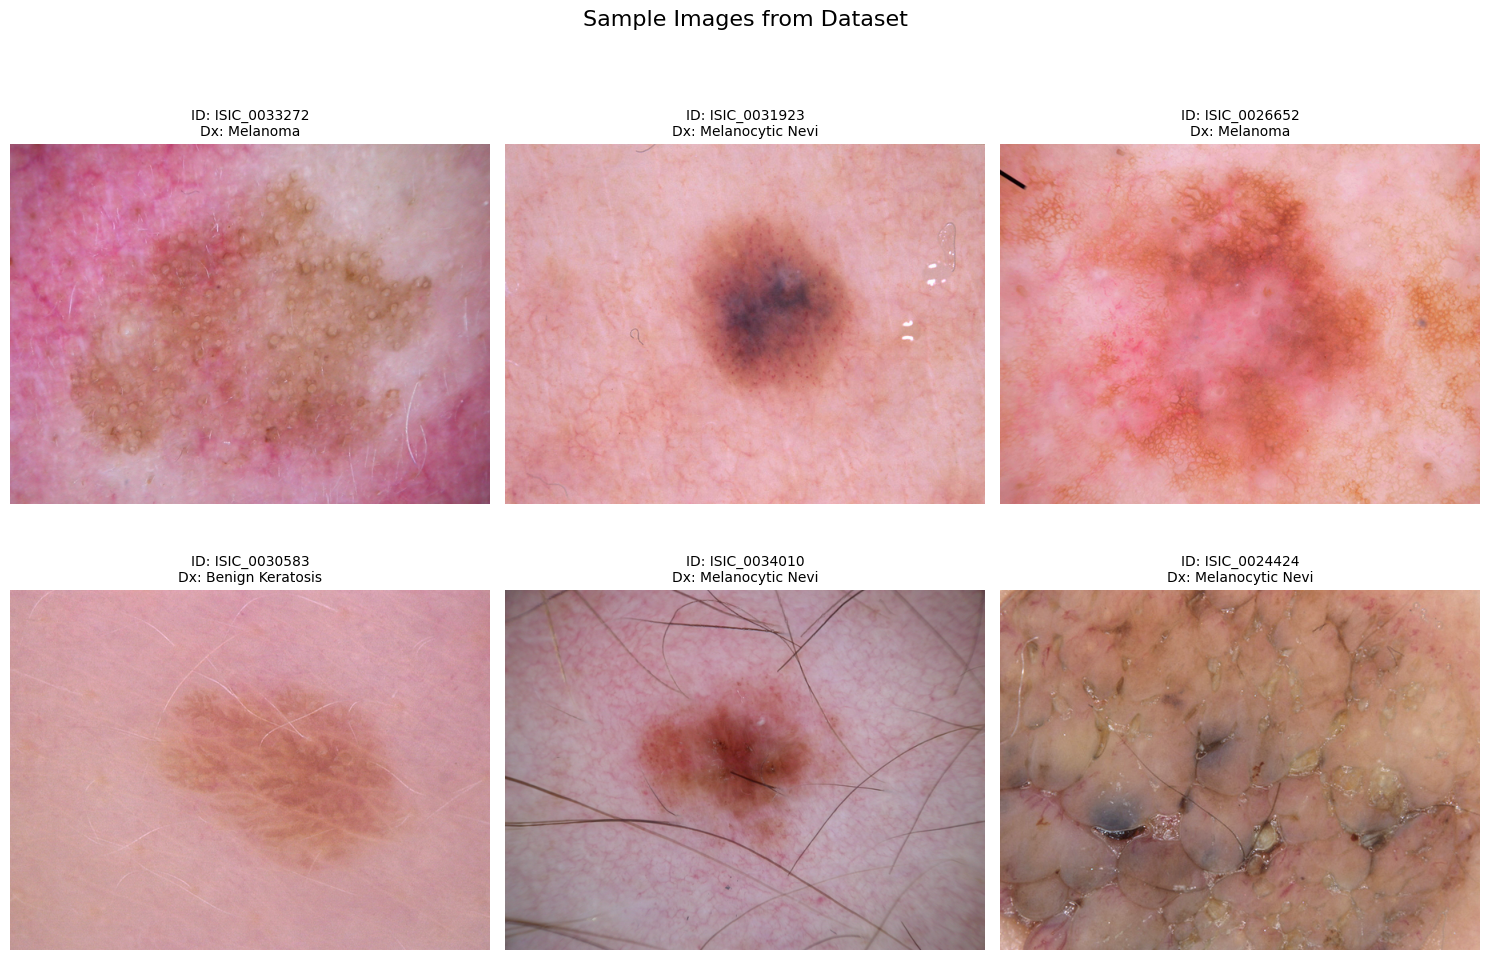

In [ ]:
# Filter out rows without image paths and sample a few images
sample_images = df.dropna(subset=['img_path']).sample(n=6, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (idx, row) in enumerate(sample_images.iterrows()):
    img_path = row['img_path']
    image_id = row['image_id']
    dx_label = row['dx']

    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"ID: {image_id}\nDx: {dx_label}", fontsize=10)
    axes[i].axis('off')

plt.suptitle('Sample Images from Dataset', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# LABELING

In [ ]:
METADATA_PATH     = df
IMAGE_SOURCE_DIRS = ['/content/HAM10000']
OUTPUT_BASE_DIR   = '/content/drive/MyDrive/big data/HAM1000'

# Load metadata
def sanitize(label: str) -> str:
    return label.strip().replace(' ', '_').replace('/', '_')

# Buat folder per label
for label in df['dx'].unique():
    os.makedirs(os.path.join(OUTPUT_BASE_DIR, sanitize(label)), exist_ok=True)

# Cari gambar di folder sumber
def find_image(image_id: str) -> str | None:
    for src_dir in IMAGE_SOURCE_DIRS:
        path = os.path.join(src_dir, f'{image_id}.jpg')
        if os.path.exists(path):
            return path
    return None

# Salin gambar ke Drive
success, failed = 0, 0

for _, row in tqdm(df.iterrows(), total=len(df), desc="Menyalin ke Drive"):
    dest = os.path.join(OUTPUT_BASE_DIR, sanitize(row['dx']), f"{row['image_id']}.jpg")
    if os.path.exists(dest):
        success += 1
        continue
    src = find_image(row['image_id'])
    if src:
        try:
            shutil.copy2(src, dest)
            success += 1
        except Exception:
            failed += 1
    else:
        failed += 1

print(f"Selesai — berhasil: {success} | gagal: {failed}")

Menyalin ke Drive: 100%|██████████| 10015/10015 [04:13<00:00, 39.51it/s]

Selesai — berhasil: 10015 | gagal: 0


In [ ]:
image_data_dir = '/content/drive/MyDrive/big data/HAM1000'

if os.path.exists(image_data_dir):
    print(f"Direktori '{image_data_dir}' ditemukan.")

    subdirectories = [d for d in os.listdir(image_data_dir) if os.path.isdir(os.path.join(image_data_dir, d))]
    print(f"Total {len(subdirectories)} sub-direktori (label dx) ditemukan:")

    total_images_in_organized_dir = 0
    for subdir in sorted(subdirectories):
        subdir_path = os.path.join(image_data_dir, subdir)
        images_in_subdir = [f for f in os.listdir(subdir_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
        print(f"  - '{subdir}': {len(images_in_subdir)} gambar")
        total_images_in_organized_dir += len(images_in_subdir)

    print(f"\nTotal semua gambar dalam '{image_data_dir}': {total_images_in_organized_dir}")
else:
    print(f"Direktori '{image_data_dir}' tidak ditemukan. Pastikan data sudah disalin dengan benar.")

Direktori '/content/drive/MyDrive/big data/HAM1000' ditemukan.
Total 7 sub-direktori (label dx) ditemukan:
  - 'Actinic_Keratosis': 327 gambar
  - 'Basal_Cell_Carcinoma': 514 gambar
  - 'Benign_Keratosis': 1099 gambar
  - 'Dermatofibroma': 115 gambar
  - 'Melanocytic_Nevi': 6705 gambar
  - 'Melanoma': 1113 gambar
  - 'Vascular_Lesion': 142 gambar

Total semua gambar dalam '/content/drive/MyDrive/big data/HAM1000': 10015


# METADATA DERM12345

In [ ]:
df1 = pd.read_csv('/content/derm12345_metadata_test.csv')
df1.head()

,image_id,patient_id,image_type,copyright-license,split,super_class,malignancy,main_class_1,main_class_2,sub_class,label
0,DERM_255498,PID_705848,dermoscopic,CC-BY,test,melanocytic,benign,banal,compound,acral,acb
1,DERM_892713,PID_897293,dermoscopic,CC-BY,test,melanocytic,benign,banal,compound,acral,acb
2,DERM_933091,PID_897293,dermoscopic,CC-BY,test,melanocytic,benign,banal,compound,acral,acb
3,DERM_980086,PID_897293,dermoscopic,CC-BY,test,melanocytic,benign,banal,compound,acral,acb
4,DERM_738404,PID_908846,dermoscopic,CC-BY,test,melanocytic,benign,banal,compound,acral,acb


In [ ]:
df1.shape

(2485, 11)

In [ ]:
df2 = pd.read_csv('/content/derm12345_metadata_train.csv')
df2.head()

,image_id,patient_id,image_type,copyright-license,split,super_class,malignancy,main_class_1,main_class_2,sub_class,label
0,DERM_125494,PID_130179,dermoscopic,CC-BY,train,melanocytic,benign,banal,compound,acral,acb
1,DERM_830572,PID_130179,dermoscopic,CC-BY,train,melanocytic,benign,banal,compound,acral,acb
2,DERM_135726,PID_210257,dermoscopic,CC-BY,train,melanocytic,benign,banal,compound,acral,acb
3,DERM_783499,PID_210257,dermoscopic,CC-BY,train,melanocytic,benign,banal,compound,acral,acb
4,DERM_852220,PID_253526,dermoscopic,CC-BY,train,melanocytic,benign,banal,compound,acral,acb


In [ ]:
df2.shape

(9860, 11)

# PREPROCESSING

In [ ]:
merged = pd.concat([df1, df2], ignore_index=True)
print("Shape of merged dataset:", merged.shape)
print("Head of merged dataset:")
display(merged.head())
print("Tail of merged dataset:")
display(merged.tail())

Shape of merged dataset: (12345, 11)
Head of merged dataset:


,image_id,patient_id,image_type,copyright-license,split,super_class,malignancy,main_class_1,main_class_2,sub_class,label
0,DERM_255498,PID_705848,dermoscopic,CC-BY,test,melanocytic,benign,banal,compound,acral,acb
1,DERM_892713,PID_897293,dermoscopic,CC-BY,test,melanocytic,benign,banal,compound,acral,acb
2,DERM_933091,PID_897293,dermoscopic,CC-BY,test,melanocytic,benign,banal,compound,acral,acb
3,DERM_980086,PID_897293,dermoscopic,CC-BY,test,melanocytic,benign,banal,compound,acral,acb
4,DERM_738404,PID_908846,dermoscopic,CC-BY,test,melanocytic,benign,banal,compound,acral,acb


Tail of merged dataset:


,image_id,patient_id,image_type,copyright-license,split,super_class,malignancy,main_class_1,main_class_2,sub_class,label
12340,DERM_194546,PID_625797,dermoscopic,CC-BY,train,melanocytic,benign,dysplastic,junctional,spitz_reed,srjd
12341,DERM_563817,PID_625797,dermoscopic,CC-BY,train,melanocytic,benign,dysplastic,junctional,spitz_reed,srjd
12342,DERM_707293,PID_625797,dermoscopic,CC-BY,train,melanocytic,benign,dysplastic,junctional,spitz_reed,srjd
12343,DERM_294294,PID_766694,dermoscopic,CC-BY,train,melanocytic,benign,dysplastic,junctional,spitz_reed,srjd
12344,DERM_384728,PID_766694,dermoscopic,CC-BY,train,melanocytic,benign,dysplastic,junctional,spitz_reed,srjd


In [ ]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12345 entries, 0 to 12344
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   image_id           12345 non-null  object
 1   patient_id         12345 non-null  object
 2   image_type         12345 non-null  object
 3   copyright-license  12345 non-null  object
 4   split              12345 non-null  object
 5   super_class        12345 non-null  object
 6   malignancy         12345 non-null  object
 7   main_class_1       12345 non-null  object
 8   main_class_2       12345 non-null  object
 9   sub_class          12345 non-null  object
 10  label              12345 non-null  object
dtypes: object(11)
memory usage: 1.0+ MB


In [ ]:
merged.isnull().sum()

,0
image_id,0
patient_id,0
image_type,0
copyright-license,0
split,0
super_class,0
malignancy,0
main_class_1,0
main_class_2,0
sub_class,0


In [ ]:
merged.duplicated().sum()

np.int64(0)

In [ ]:
print(f"Duplikat image_id  : {merged['image_id'].duplicated().sum()}")
print(f"Duplikat patient_id: {merged['patient_id'].duplicated().sum()}")

Duplikat image_id  : 0
Duplikat patient_id: 10718


In [ ]:
merged = merged.drop('split', axis=1)
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12345 entries, 0 to 12344
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   image_id           12345 non-null  object
 1   patient_id         12345 non-null  object
 2   image_type         12345 non-null  object
 3   copyright-license  12345 non-null  object
 4   super_class        12345 non-null  object
 5   malignancy         12345 non-null  object
 6   main_class_1       12345 non-null  object
 7   main_class_2       12345 non-null  object
 8   sub_class          12345 non-null  object
 9   label              12345 non-null  object
dtypes: object(10)
memory usage: 964.6+ KB


# IMAGE DATASET

In [ ]:
extract_path = '/content/dermoscopic'
os.makedirs(extract_path, exist_ok=True) # Ensure the directory exists

zip_file_train_part1 = '/content/derm12345_train_part_1.zip'
zip_file_train_part2 = '/content/derm12345_train_part_2.zip'
zip_file_test = '/content/derm12345_test.zip'

print("Mengekstrak derm12345_train_part_1.zip...")
with zipfile.ZipFile(zip_file_train_part1, 'r') as z:
    z.extractall(extract_path)
print("Ekstraksi file train part 1 selesai.")

print("\nMengekstrak derm12345_train_part_2.zip...")
with zipfile.ZipFile(zip_file_train_part2, 'r') as z:
    z.extractall(extract_path)
print("Ekstraksi file train part 2 selesai.")

print("\nMengekstrak derm12345_test.zip...")
with zipfile.ZipFile(zip_file_test, 'r') as z:
    z.extractall(extract_path)
print("Ekstraksi file test selesai.")

Mengekstrak derm12345_train_part_1.zip...
Ekstraksi file train part 1 selesai.

Mengekstrak derm12345_train_part_2.zip...
Ekstraksi file train part 2 selesai.

Mengekstrak derm12345_test.zip...
Ekstraksi file test selesai.

Total gambar setelah ekstraksi: 0


In [ ]:
folder_counts = {}
for folder in sorted(os.listdir(extract_path)):
    folder_path = os.path.join(extract_path, folder)
    if os.path.isdir(folder_path):
        img_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        folder_counts[folder] = len(img_files)

print(f"Total {len(folder_counts)} sub-direktori ditemukan:")
for folder, count in folder_counts.items():
    print(f"  - '{folder}': {count} gambar")

Total 40 sub-direktori ditemukan:
  - 'acb': 37 gambar
  - 'acd': 9 gambar
  - 'ajb': 426 gambar
  - 'ajd': 288 gambar
  - 'ak': 58 gambar
  - 'alm': 60 gambar
  - 'angk': 39 gambar
  - 'anm': 76 gambar
  - 'bcc': 423 gambar
  - 'bd': 37 gambar
  - 'bdb': 163 gambar
  - 'cb': 722 gambar
  - 'ccb': 418 gambar
  - 'ccd': 32 gambar
  - 'cd': 498 gambar
  - 'ch': 12 gambar
  - 'cjb': 143 gambar
  - 'db': 560 gambar
  - 'df': 180 gambar
  - 'dfsp': 4 gambar
  - 'ha': 166 gambar
  - 'isl': 6 gambar
  - 'jb': 1223 gambar
  - 'jd': 5275 gambar
  - 'ks': 16 gambar
  - 'la': 56 gambar
  - 'lk': 8 gambar
  - 'lm': 86 gambar
  - 'lmm': 25 gambar
  - 'ls': 25 gambar
  - 'mcb': 123 gambar
  - 'mel': 153 gambar
  - 'mpd': 9 gambar
  - 'pg': 7 gambar
  - 'rd': 16 gambar
  - 'sa': 14 gambar
  - 'scc': 266 gambar
  - 'sk': 607 gambar
  - 'sl': 60 gambar
  - 'srjd': 19 gambar


In [ ]:
# Pastikan semua image_id punya file gambar yang sesuai
image_files = set()
for folder in os.listdir(extract_path):
    folder_path = os.path.join(extract_path, folder)
    if os.path.isdir(folder_path):
        for f in os.listdir(folder_path):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_files.add(os.path.splitext(f)[0])  # tanpa ekstensi

df_ids = set(merged['image_id'])
missing = df_ids - image_files
orphan = image_files - df_ids

print(f"image_id di CSV tapi tidak ada filenya : {len(missing)}")
print(f"File gambar tapi tidak ada di CSV       : {len(orphan)}")

image_id di CSV tapi tidak ada filenya : 0
File gambar tapi tidak ada di CSV       : 0
